Prediction of CO2 emissions

Data exploration and visualisation

1.Import Required libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_cleaned.csv to data_cleaned.csv


In [ ]:
data = pd.read_csv("data_cleaned.csv")

In [ ]:
display(data.head())
display(data.info())

,country,year,cereal_yield,fdi_perc_gdp,en_per_gdp,en_per_cap,co2_ttl,co2_per_cap,co2_per_gdp,pop_urb_aggl_perc,prot_area_perc,gdp,gni_per_cap,under_5_mort_rate,pop_growth_perc,pop,urb_pop_growth_perc,urb_pop
0,AGO,1991,417.4,5.449515,179.271884,565.451027,4367.397,0.409949,129.971142,15.290728,12.399822,1.219375e+10,820.0,239.1,3.034866,10653515.0,6.687032,4.099473e+06
1,ARE,1991,1594.0,0.076475,245.977706,12262.388130,57010.849,29.851550,598.807980,26.377204,0.266886,3.391964e+10,19340.0,20.5,5.442852,1909812.0,5.265704,1.507988e+06
2,ARG,1991,2666.1,1.285579,173.122857,1434.960601,117021.304,3.536073,426.614517,39.119646,4.772468,1.897200e+11,3960.0,25.8,1.372593,33093579.0,1.762636,2.890393e+07
3,AUS,1991,1603.3,1.306912,208.686644,4926.727783,281530.258,16.288490,689.948873,60.356798,7.915273,3.299655e+11,18380.0,8.6,1.274577,17284000.0,1.438378,1.478473e+07
4,AUT,1991,5463.0,0.209142,128.939160,3381.073790,65888.656,8.448456,322.186648,19.746121,20.991143,1.721664e+11,21200.0,8.9,1.134999,7798899.0,1.134999,5.131676e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              1700 non-null   object 
 1   year                 1700 non-null   int64  
 2   cereal_yield         1700 non-null   float64
 3   fdi_perc_gdp         1700 non-null   float64
 4   en_per_gdp           1700 non-null   float64
 5   en_per_cap           1700 non-null   float64
 6   co2_ttl              1700 non-null   float64
 7   co2_per_cap          1700 non-null   float64
 8   co2_per_gdp          1700 non-null   float64
 9   pop_urb_aggl_perc    1700 non-null   float64
 10  prot_area_perc       1700 non-null   float64
 11  gdp                  1700 non-null   float64
 12  gni_per_cap          1700 non-null   float64
 13  under_5_mort_rate    1700 non-null   float64
 14  pop_growth_perc      1700 non-null   float64
 15  pop                  1700 non-null   f

None

Decribing and transposing

In [ ]:
print("Descriptive statistics:")
data.describe().T

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
year,1700.0,1.999571e+03,5.143070e+00,1.991000e+03,1.995000e+03,2.000000e+03,2.004000e+03,2.008000e+03
cereal_yield,1700.0,3.013318e+03,1.796206e+03,1.757000e+02,1.683365e+03,2.584800e+03,3.933400e+03,8.410800e+03
fdi_perc_gdp,1700.0,2.948940e+00,3.949722e+00,-1.502768e+01,8.341052e-01,1.993220e+00,3.702149e+00,5.137395e+01
en_per_gdp,1700.0,2.498227e+02,1.861950e+02,6.633537e+01,1.363205e+02,1.976249e+02,2.864749e+02,1.383380e+03
en_per_cap,1700.0,1.968980e+03,1.959420e+03,1.165115e+02,5.428828e+02,1.089226e+03,2.893996e+03,1.260784e+04
co2_ttl,1700.0,9.793999e+05,3.235692e+06,7.077310e+02,1.462125e+04,7.728386e+04,3.708446e+05,3.064936e+07
co2_per_cap,1700.0,4.676663e+00,4.906273e+00,2.941071e-02,9.227695e-01,3.093346e+00,7.441195e+00,3.710650e+01
co2_per_gdp,1700.0,4.823038e+02,3.921922e+02,4.555259e+01,2.571396e+02,3.684156e+02,5.869730e+02,3.343454e+03
pop_urb_aggl_perc,1700.0,2.148013e+01,1.210516e+01,3.526316e+00,1.238395e+01,1.852596e+01,2.898832e+01,6.050578e+01
prot_area_perc,1700.0,1.220179e+01,9.116682e+00,0.000000e+00,5.839844e+00,1.029379e+01,1.659930e+01,5.374983e+01


abbrevations:
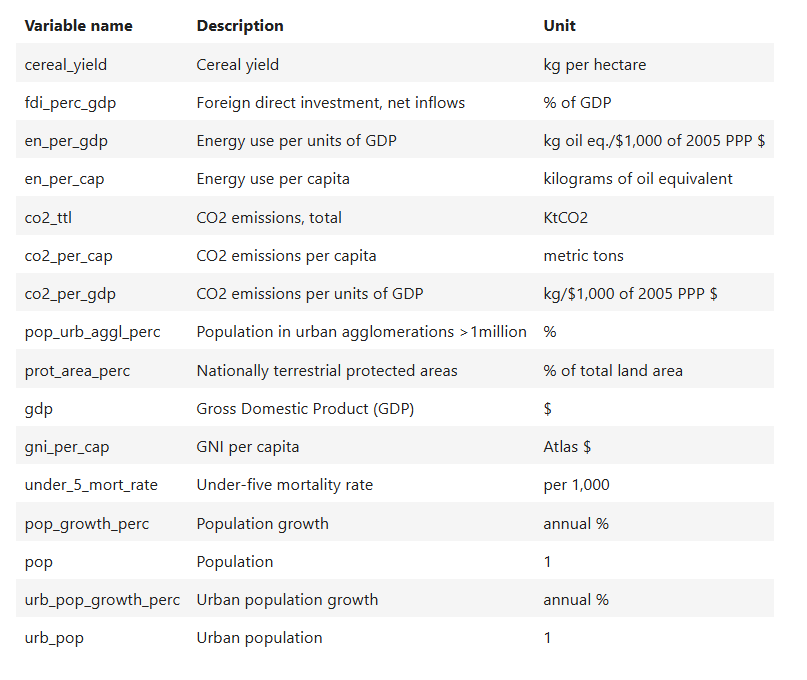

Visualisations:
co2 emissions per capita over time
1991 -2008

In [ ]:
#group by year and calculate CO2 pre capita
df_yearly_avg = data.groupby('year')['co2_per_cap'].mean().reset_index()

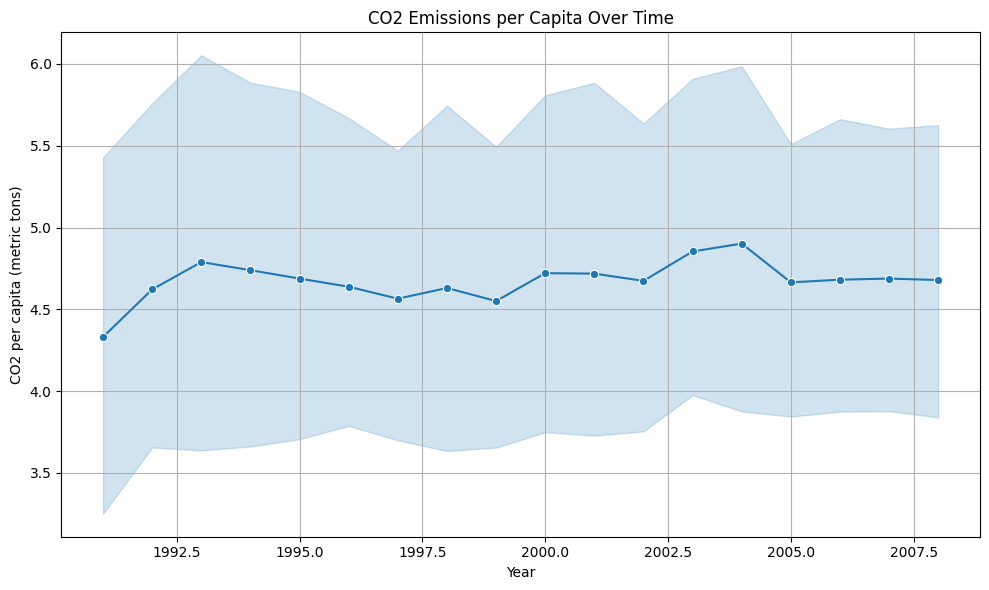

In [ ]:
#plot
plt.figure(figsize=(10,6))
sns.lineplot(data=data, x='year', y='co2_per_cap', marker='o')
plt.title('CO2 Emissions per Capita Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 per capita (metric tons)')
plt.grid(True)
plt.tight_layout()
plt.show()

despite some fluctuations the global per capita co2 emissions remained largely steady between 1991 - 2000 the range was between 4 to 5metric tons average was around 4.6 metric tons.

plot between total co2 emissions and populations

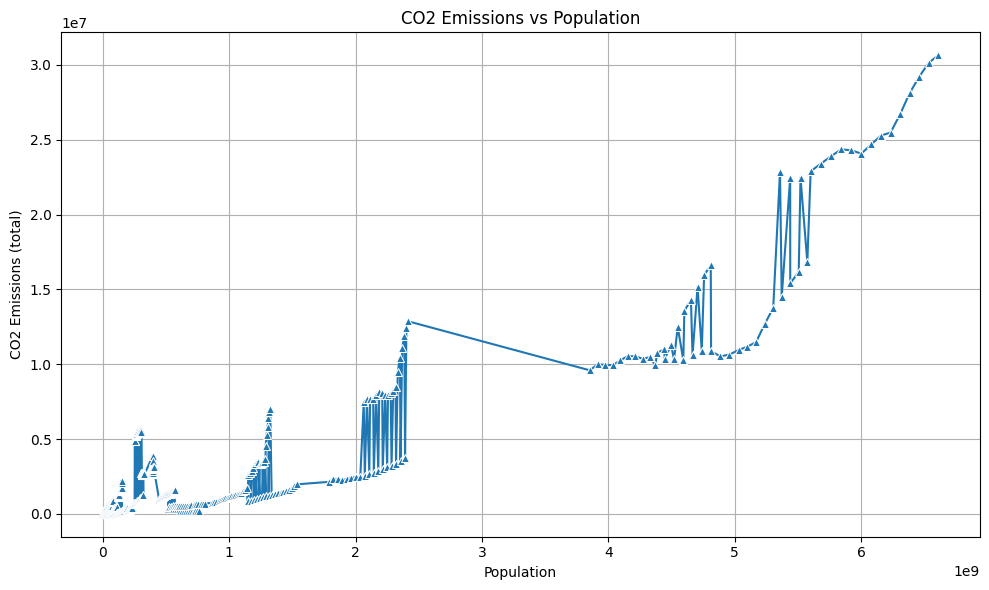

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=data, x='pop',y='co2_ttl', marker='^')
plt.title("CO2 Emissions vs Population")
plt.xlabel("Population")
plt.ylabel("CO2 Emissions (total)")
plt.grid(True)
plt.tight_layout()
plt.show()

As we can see, countries with higher population tends to have high co2 emissions. Therefore we can conclude that populations holds an important role in co2 emissions.

Hypothesis:
CO₂ emissions are influenced by country-specific features such as energy use, population metrics, GDP, FDI, and land use — and can be predicted from them. Co2_emissions will be treated as the dependent variable.

2.Feature Engineering

A column for total energy use:

In [ ]:
data['eng_ttl'] = data['en_per_gdp']*data['gdp']/1000

In [ ]:
data['eng_ttl']

,eng_ttl
0,2.185996e+09
1,8.343475e+09
2,3.284487e+10
3,6.885939e+10
4,2.219899e+10
...,...
1695,2.402882e+10
1696,3.826780e+09
1697,8.814178e+10
1698,1.393073e+10


choosing the best unit for co2 emission and energy use

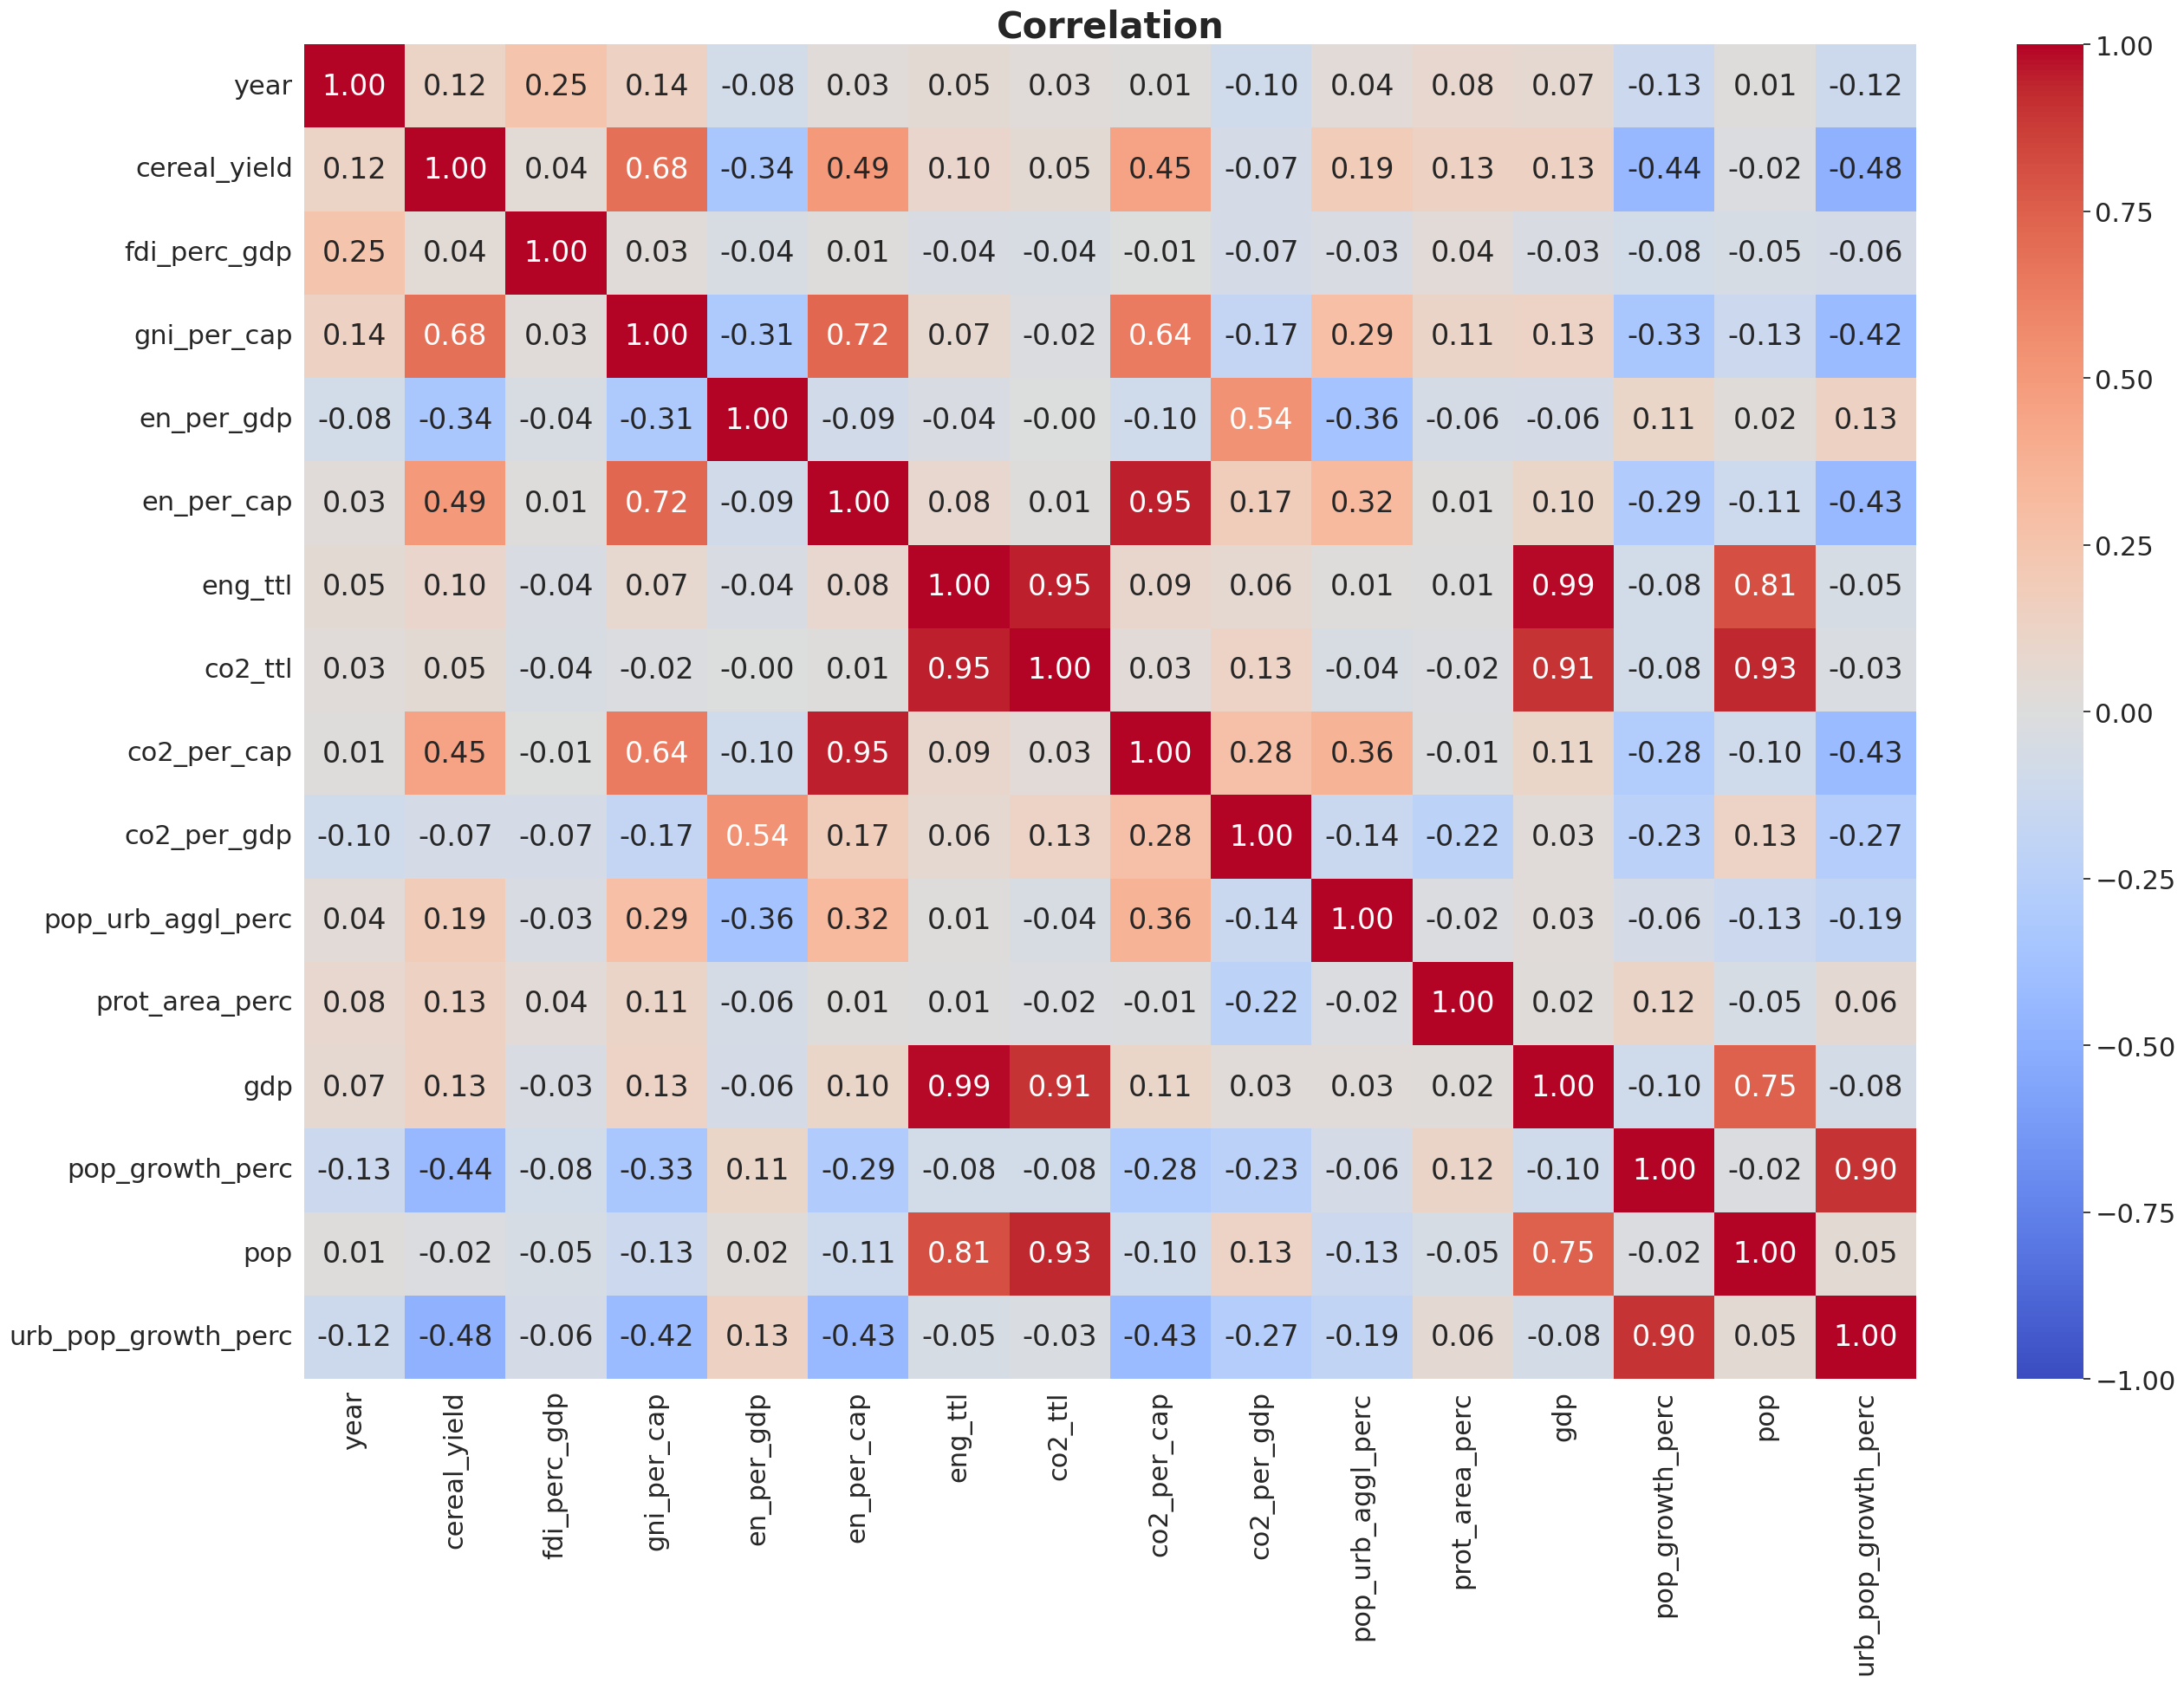

In [ ]:
features_all = data[['year','cereal_yield','fdi_perc_gdp','gni_per_cap',
                     'en_per_gdp', 'en_per_cap', 'eng_ttl', 'co2_ttl', 'co2_per_cap',
                     'co2_per_gdp', 'pop_urb_aggl_perc', 'prot_area_perc', 'gdp',
                     'pop_growth_perc', 'pop', 'urb_pop_growth_perc']]

  #plot a correlation of all features
  #correlation metrix
sns.set_theme(font_scale=2)
f,ax=plt.subplots(figsize=(30,20))
sns.heatmap(features_all.corr(), annot=True , cmap='coolwarm', fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title('Correlation', fontsize=30, weight='bold')
plt.show()
sns.set_theme(font_scale=1)


In [ ]:
features_for_vif = data[['cereal_yield','gni_per_cap','en_per_gdp','eng_ttl','co2_ttl','co2_per_cap', 'en_per_cap','co2_per_gdp',
                     'pop_urb_aggl_perc', 'gdp',  'pop_growth_perc', 'urb_pop_growth_perc']]
vif_data = pd.DataFrame()
vif_data["feature"] = features_for_vif.columns # Use the columns from the features_for_vif DataFrame
vif_data["VIF"] = [variance_inflation_factor(features_for_vif.values, i)
                   for i in range(features_for_vif.shape[1])] # Use the values and number of columns from features_for_vif
print(vif_data)


VIF values measure how much a feature's variance is inflated due to multicollinearity with other features:

VIF < 5 → Low multicollinearity (generally safe)

VIF 5–10 → Moderate multicollinearity (potential issue)

VIF > 10 → High multicollinearity (problematic, should consider dropping or combining)

In [ ]:
# Features to drop (due to high VIF)
features_to_drop = ['eng_ttl', 'gdp', 'co2_ttl']

# Drop them from the features_for_vif DataFrame
features_reduced = features_for_vif.drop(columns=features_to_drop)

# Confirm what's left
print("Remaining features after VIF reduction:")
print(features_reduced.columns.tolist())


In [ ]:
features_all[['cereal_yield', 'gni_per_cap', 'en_per_gdp', 'co2_per_cap', 'en_per_cap', 'co2_per_gdp', 'pop_urb_aggl_perc', 'pop_growth_perc', 'urb_pop_growth_perc']]

In [ ]:
labels_dict = {'gni_per_cap':'GNI per capita [Atlas $]',
               'gdp':'Gross Domestic Product [$]',
               'cereal_yield':'Cereal yield [kg/ha]',
               'pop_urb_aggl_perc': 'Population in urban agglomerations > 1mln [%]',
               'urb_pop_growth_perc':'Urban population growth [annual %]',
               'pop_growth_perc': 'Population growth [annual %]',
               'co2_per_cap':'CO2 emissions per capita [t]',
               'en_per_cap':'Energy use per capita [kg oil eq]' }

Choose a subset of countries to plot

In [ ]:
# get unique values in country column
unique_countries = data['country'].unique()
unique_countries

CO₂ Emissions per Capita Over Time (Selected Countries)

In [ ]:
# Select countries to compare
selected_countries = ['IND', 'USA', 'PAK', 'RUS', 'NZL']

# Use the correct DataFrame variable 'data' and column names 'country', 'year', and 'co2_per_cap'
df_selected = data[data['country'].isin(selected_countries)]

# Plot
plt.figure(figsize=(12, 6))
# Use the correct DataFrame variable 'df_selected' and column names 'year' and 'co2_per_cap' for plotting
sns.lineplot(data=df_selected, x='year', y='co2_per_cap', hue='country', marker='o')
plt.title('CO₂ Emissions per Capita Over Time (Selected Countries)')
plt.ylabel('CO₂ per Capita (metric tons)')
plt.xlabel('Year')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

Analysis:
1. Highest co2 emission per capita is to be shown by USA from over 1990 to 2000.
2. A decline in co2 emissions has been shown by Russia from 1992 to 2000.
3. A consistent 7 metric ton emissions of co2 has been potrayed by NZL after which they had a slight increase to 9 metric tons.
4. PAK and IND have been showing very low emmsions but a small upward trend has been seen indicating development.

In [ ]:
# select only rows for half of the countries chosen randomly in order to ensure better visibility
chosen_countries=['IND', 'LMC', 'LMY', 'MAR', 'MEX', 'MIC', 'MNA', 'MOZ', 'MYS',
'NGA', 'NLD', 'NZL', 'PAK', 'PAN', 'PER', 'PHL', 'PRT', 'PRY',
'ROM', 'SAS', 'SAU', 'SDN', 'SEN', 'SLV', 'SSA', 'SWE', 'SYR',
'TGO', 'THA', 'TUR', 'TZA', 'UMC', 'URY', 'USA', 'VEN', 'VNM',
'WLD', 'ZAF', 'ZAR', 'ZMB', 'ECA', 'POL', 'RUS', 'UKR', 'YEM',
'ETH', 'BEL']

features_chosen = data[data['country'].isin(chosen_countries)].copy()

In [ ]:
sns.set_theme(font_scale=1.3)
sns.pairplot(data=features_chosen, hue='country')


Notable Outliers: United Arab Emirates
Another significant observation is the cluster of orange outlier points with CO₂ emissions per capita ranging between 25 and 40 metric tons, all attributed to the United Arab Emirates (ARE). While there are other country-specific outliers, they do not substantially impact the overall trend.

In [ ]:
#choose features and label columns
feature_cols = ['cereal_yield', 'gni_per_cap', 'en_per_gdp', 'co2_per_cap', 'en_per_cap', 'co2_per_gdp', 'pop_urb_aggl_perc', 'pop_growth_perc', 'urb_pop_growth_perc', 'country']

# Keep as DataFrame for filtering
features_for_plot = data[feature_cols].copy() # Create a copy to avoid SettingWithCopyWarning

# remove the ARE outliers from the DataFrame used for plotting
features_for_plot = features_for_plot[features_for_plot['country']!='ARE']

After removing the outliers of a single country, the trends have become even more visible.

The following plot shows the relationsip between 4 variables:

In [ ]:
# 4d plot

sns.set_theme(style="whitegrid", font_scale=2)

cmap = sns.cubehelix_palette(rot=-.2, as_cmap=True)
g = sns.relplot(
    data=features_for_plot, # Use the DataFrame specifically prepared for plotting
    x="urb_pop_growth_perc", y="co2_per_cap",
    hue="en_per_cap", size="pop_urb_aggl_perc",
    palette=cmap, sizes=(10, 200),
    height=10, aspect= 4/3
)

g.ax.set_xlabel(labels_dict['urb_pop_growth_perc'])
g.ax.set_ylabel(labels_dict['co2_per_cap'])

Targeted plotting of key relationships has provided useful insights for predictive analysis:

CO₂ emissions and energy use per capita are linked to more features and will be kept for further analysis.

Population count is no longer relevant and will be removed.

CO₂ emissions per capita show a strong linear relationship with energy use and nonlinear patterns with other variables.

Both country-specific and overall global trends are visible. In some cases, global trends split into different paths for clusters of countries.

Outlier groups, especially those from the United Arab Emirates (ARE), stand out from global patterns and should be considered when selecting data.

The nonlinear nature of most relationships and the presence of country-based clusters suggest using machine learning models that handle nonlinearities and grouped data well (e.g., Random Forest), rather than those suited for purely linear patterns (e.g., Linear Regression).

